# Economia Circular na União Europeia — Eurostat

Este notebook analisa o indicador de taxa de utilização circular de materiais disponibilizado pelo Eurostat.

O indicador permite contextualizar o nível de materiais reciclados ou reintroduzidos na economia em relação ao uso total de materiais.

## 1. Objetivo da análise

Analisar a evolução da taxa de utilização circular de materiais na União Europeia e comparar os resultados entre os países.

O indicador é utilizado como contexto para discutir economia circular, reutilização e redução da dependência de matérias-primas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carregamento dos dados

Os dados foram obtidos do Eurostat e correspondem ao indicador de taxa de utilização circular de materiais.

In [8]:
from google.colab import files

uploaded = files.upload()

Saving sdg_12_41_page_spreadsheet.xlsx to sdg_12_41_page_spreadsheet.xlsx


In [12]:
eurostat_dados = pd.read_excel(
    "sdg_12_41_page_spreadsheet.xlsx",
    sheet_name="Sheet 1"
)

display(eurostat_dados.head(10))

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Data extracted on 06/10/2026 00:55:45 from [ESTAT],Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,Dataset:,Circular material use rate [sdg_12_41],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last updated:,24/11/2025 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Time frequency,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unit of measure,NaN,Percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,TIME,2004,NaN,2005,NaN,2006,NaN,2007,NaN,2008,...,2020,NaN,2021,NaN,2022,NaN,2023,NaN,2024,NaN
7,GEO (Labels),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,European Union - 27 countries (from 2020),8.2,NaN,8.7,NaN,9,NaN,8.8,NaN,9.1,...,11.2,NaN,11.1,NaN,11.4,NaN,12.1,NaN,12.2,i
9,Euro area – 21 countries (from 2026),:,NaN,:,NaN,:,NaN,:,NaN,:,...,:,NaN,:,NaN,:,NaN,:,NaN,:,NaN


## 3. Conhecendo a estrutura dos dados

Antes do tratamento, é necessário verificar a estrutura da base, incluindo quantidade de linhas, colunas e informações disponíveis.

In [13]:
print("Quantidade de linhas:", eurostat_dados.shape[0])
print("Quantidade de colunas:", eurostat_dados.shape[1])

Quantidade de linhas: 47
Quantidade de colunas: 43


In [14]:
print("Colunas disponíveis:")
print(eurostat_dados.columns.tolist())

Colunas disponíveis:
['Data extracted on 06/10/2026 00:55:45 from [ESTAT]', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42']


In [15]:
display(eurostat_dados)

,Data extracted on 06/10/2026 00:55:45 from [ESTAT],Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,Dataset:,Circular material use rate [sdg_12_41],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last updated:,24/11/2025 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Time frequency,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unit of measure,NaN,Percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,TIME,2004,NaN,2005,NaN,2006,NaN,2007,NaN,2008,...,2020,NaN,2021,NaN,2022,NaN,2023,NaN,2024,NaN
7,GEO (Labels),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,European Union - 27 countries (from 2020),8.2,NaN,8.7,NaN,9,NaN,8.8,NaN,9.1,...,11.2,NaN,11.1,NaN,11.4,NaN,12.1,NaN,12.2,i
9,Euro area – 21 countries (from 2026),:,NaN,:,NaN,:,NaN,:,NaN,:,...,:,NaN,:,NaN,:,NaN,:,NaN,:,NaN


In [16]:
display(eurostat_dados)



,Data extracted on 06/10/2026 00:55:45 from [ESTAT],Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42
0,Dataset:,Circular material use rate [sdg_12_41],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Last updated:,24/11/2025 23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Time frequency,NaN,Annual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Unit of measure,NaN,Percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,TIME,2004,NaN,2005,NaN,2006,NaN,2007,NaN,2008,...,2020,NaN,2021,NaN,2022,NaN,2023,NaN,2024,NaN
7,GEO (Labels),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,European Union - 27 countries (from 2020),8.2,NaN,8.7,NaN,9,NaN,8.8,NaN,9.1,...,11.2,NaN,11.1,NaN,11.4,NaN,12.1,NaN,12.2,i
9,Euro area – 21 countries (from 2026),:,NaN,:,NaN,:,NaN,:,NaN,:,...,:,NaN,:,NaN,:,NaN,:,NaN,:,NaN


## 3. Tratamento e organização dos dados

A base original do Eurostat contém informações de identificação, metadados, valores anuais e indicadores de qualidade.

Para a análise, foram selecionadas as linhas referentes aos países e à União Europeia e as colunas correspondentes aos anos de 2004 a 2024.

Os valores ":" representam dados não disponíveis e serão convertidos em valores ausentes.

In [18]:
# Selecionar as linhas que contêm a União Europeia e os países
dados = eurostat_dados.iloc[8:41].copy()

# A primeira coluna contém o nome do país/região
coluna_pais = eurostat_dados.columns[0]

# Os valores dos anos estão nas colunas ímpares:
# 1 = 2004, 3 = 2005, 5 = 2006, ..., 41 = 2024
colunas_anos = list(range(1, 42, 2))

# Selecionar país + valores dos anos
eurostat_limpo = dados.iloc[:, [0] + colunas_anos].copy()

# Criar nomes das colunas
anos = list(range(2004, 2025))

eurostat_limpo.columns = ["Pais"] + anos

# Substituir ":" por valores ausentes
eurostat_limpo = eurostat_limpo.replace(":", pd.NA)

# Converter os valores para números
for ano in anos:
    eurostat_limpo[ano] = pd.to_numeric(
        eurostat_limpo[ano],
        errors="coerce"
    )

# Mostrar a base tratada
display(eurostat_limpo)

,Pais,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
8,European Union - 27 countries (from 2020),8.2,8.7,9.0,8.8,9.1,10.4,10.7,10.2,11.0,...,11.2,11.4,11.5,11.6,11.1,11.2,11.1,11.4,12.1,12.2
9,Euro area – 21 countries (from 2026),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,Euro area – 20 countries (2023-2025),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Belgium,NaN,NaN,NaN,NaN,NaN,NaN,13.5,14.4,17.3,...,18.0,18.0,18.9,20.6,20.5,22.9,21.3,17.8,21.8,22.7
12,Bulgaria,NaN,NaN,NaN,NaN,NaN,NaN,2.1,1.8,1.8,...,3.1,4.3,3.4,2.4,4.0,5.8,4.3,3.0,4.9,5.0
13,Czechia,NaN,NaN,NaN,NaN,NaN,NaN,5.3,5.4,6.3,...,6.9,7.5,9.1,10.5,10.6,11.5,11.0,11.3,13.6,14.8
14,Denmark,NaN,NaN,NaN,NaN,NaN,NaN,8.0,7.0,6.4,...,8.3,7.8,7.9,8.0,7.6,7.5,8.4,9.1,9.3,9.4
15,Germany,NaN,NaN,NaN,NaN,NaN,NaN,11.2,10.6,11.0,...,11.7,11.8,11.7,12.1,12.5,12.9,12.3,12.6,14.5,14.8
16,Estonia,NaN,NaN,NaN,NaN,NaN,NaN,9.0,14.5,19.2,...,11.4,11.9,12.5,13.8,15.2,16.3,19.9,21.8,20.5,20.5
17,Ireland,NaN,NaN,NaN,NaN,NaN,NaN,1.9,2.2,1.9,...,2.1,2.0,1.9,1.9,1.8,1.8,2.0,2.1,2.1,2.0


## 4. Verificação dos dados tratados

Após a organização da base, são verificadas algumas informações para confirmar se os valores foram carregados corretamente.

In [19]:
print("Quantidade de registros:", len(eurostat_limpo))
print("Quantidade de anos:", len(anos))

display(eurostat_limpo[["Pais", 2020, 2021, 2022, 2023, 2024]])

Quantidade de registros: 33
Quantidade de anos: 21


,Pais,2020,2021,2022,2023,2024
8,European Union - 27 countries (from 2020),11.2,11.1,11.4,12.1,12.2
9,Euro area – 21 countries (from 2026),NaN,NaN,NaN,NaN,NaN
10,Euro area – 20 countries (2023-2025),NaN,NaN,NaN,NaN,NaN
11,Belgium,22.9,21.3,17.8,21.8,22.7
12,Bulgaria,5.8,4.3,3.0,4.9,5.0
13,Czechia,11.5,11.0,11.3,13.6,14.8
14,Denmark,7.5,8.4,9.1,9.3,9.4
15,Germany,12.9,12.3,12.6,14.5,14.8
16,Estonia,16.3,19.9,21.8,20.5,20.5
17,Ireland,1.8,2.0,2.1,2.1,2.0


## 5. Evolução da União Europeia

Nesta etapa é analisada especificamente a evolução do indicador para a União Europeia formada por 27 países.

In [20]:
eu27 = eurostat_limpo[
    eurostat_limpo["Pais"] == "European Union - 27 countries (from 2020)"
].iloc[0]

eu27_evolucao = pd.DataFrame({
    "Ano": anos,
    "Taxa": [eu27[ano] for ano in anos]
})

display(eu27_evolucao)

,Ano,Taxa
0,2004,8.2
1,2005,8.7
2,2006,9.0
3,2007,8.8
4,2008,9.1
5,2009,10.4
6,2010,10.7
7,2011,10.2
8,2012,11.0
9,2013,11.2


## 6. Evolução da taxa de utilização circular de materiais na União Europeia

O gráfico apresenta a evolução da taxa de utilização circular de materiais na União Europeia entre 2004 e 2024.

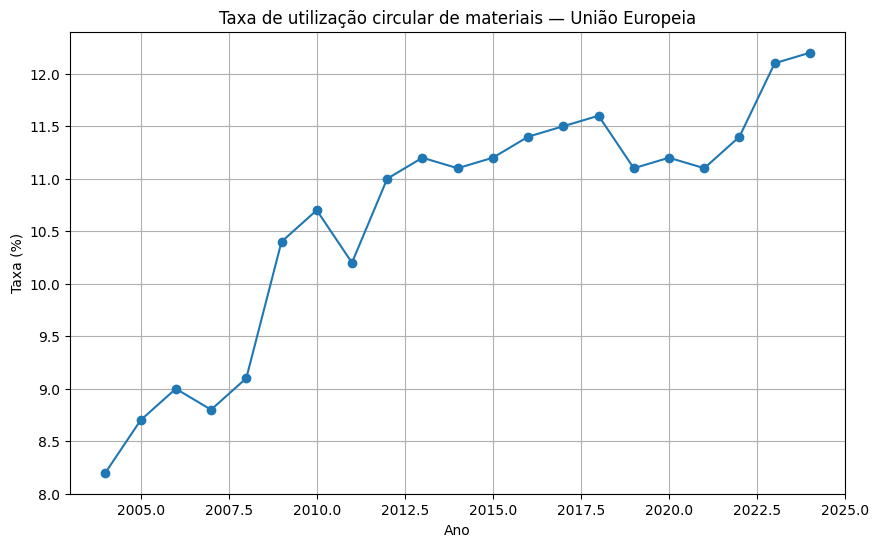

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    eu27_evolucao["Ano"],
    eu27_evolucao["Taxa"],
    marker="o"
)

plt.title(
    "Taxa de utilização circular de materiais — União Europeia"
)

plt.xlabel("Ano")
plt.ylabel("Taxa (%)")

plt.grid(True)

plt.show()

## 7. Países com maiores taxas de utilização circular em 2024

Nesta etapa são identificados os países que apresentaram os maiores valores da taxa de utilização circular de materiais em 2024.

Os agregados estatísticos, como a União Europeia e a Área do Euro, não são considerados no ranking de países.

In [22]:
# Lista de agregados que não serão considerados como países
agregados = [
    "European Union - 27 countries (from 2020)",
    "Euro area – 21 countries (from 2026)",
    "Euro area – 20 countries (2023-2025)"
]

ranking_2024 = eurostat_limpo[
    ~eurostat_limpo["Pais"].isin(agregados)
][["Pais", 2024]].dropna()

ranking_2024 = ranking_2024.sort_values(
    2024,
    ascending=False
).head(10)

display(ranking_2024)

,Pais,2024
29,Netherlands,32.7
11,Belgium,22.7
22,Italy,21.6
16,Estonia,20.5
28,Malta,18.6
20,France,17.8
30,Austria,15.2
15,Germany,14.8
13,Czechia,14.8
35,Slovakia,12.2


## 8. Ranking dos países em 2024

O gráfico apresenta os dez países com maiores taxas de utilização circular de materiais em 2024.

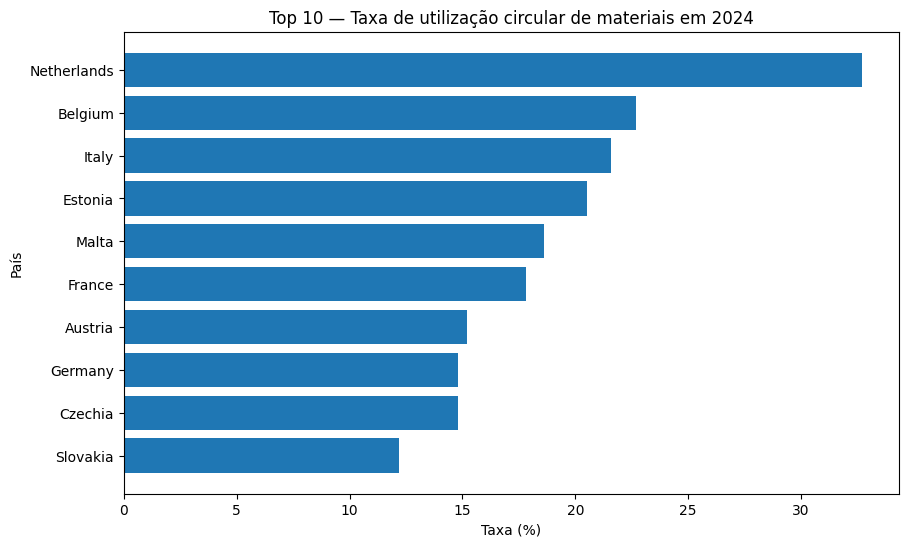

In [23]:
plt.figure(figsize=(10, 6))

plt.barh(
    ranking_2024["Pais"][::-1],
    ranking_2024[2024][::-1]
)

plt.title(
    "Top 10 — Taxa de utilização circular de materiais em 2024"
)

plt.xlabel("Taxa (%)")
plt.ylabel("País")

plt.show()

## 9. Evolução da taxa entre 2010 e 2024

Nesta etapa é analisada a variação da taxa de utilização circular de materiais entre 2010 e 2024.

A variação é apresentada em pontos percentuais.

In [24]:
evolucao = eurostat_limpo[
    ~eurostat_limpo["Pais"].isin(agregados)
][["Pais", 2010, 2024]].dropna()

evolucao["Variacao_pontos_percentuais"] = (
    evolucao[2024] - evolucao[2010]
)

evolucao = evolucao.sort_values(
    "Variacao_pontos_percentuais",
    ascending=False
)

display(evolucao)

,Pais,2010,2024,Variacao_pontos_percentuais
28,Malta,5.3,18.6,13.3
16,Estonia,9.0,20.5,11.5
22,Italy,11.3,21.6,10.3
13,Czechia,5.3,14.8,9.5
11,Belgium,13.5,22.7,9.2
30,Austria,6.8,15.2,8.4
29,Netherlands,24.8,32.7,7.9
35,Slovakia,5.0,12.2,7.2
24,Latvia,1.2,6.8,5.6
21,Croatia,1.6,5.9,4.3


## 10. Países com maior crescimento entre 2010 e 2024

Os resultados permitem identificar os países que apresentaram os maiores aumentos na taxa de utilização circular de materiais durante o período analisado.

In [25]:
top_crescimento = evolucao.head(10)

display(top_crescimento)

,Pais,2010,2024,Variacao_pontos_percentuais
28,Malta,5.3,18.6,13.3
16,Estonia,9.0,20.5,11.5
22,Italy,11.3,21.6,10.3
13,Czechia,5.3,14.8,9.5
11,Belgium,13.5,22.7,9.2
30,Austria,6.8,15.2,8.4
29,Netherlands,24.8,32.7,7.9
35,Slovakia,5.0,12.2,7.2
24,Latvia,1.2,6.8,5.6
21,Croatia,1.6,5.9,4.3


## 11. Maiores aumentos na taxa de utilização circular

O gráfico apresenta os países que tiveram os maiores aumentos em pontos percentuais entre 2010 e 2024.

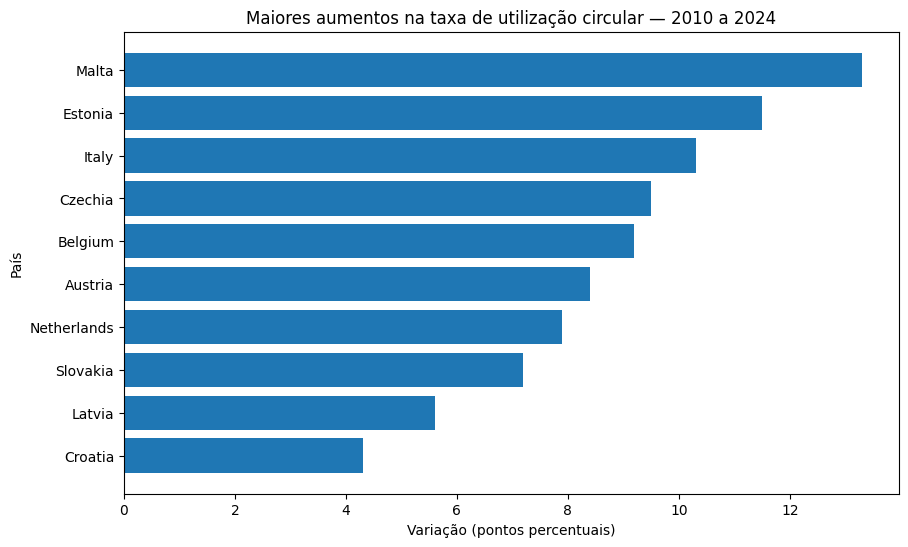

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_crescimento["Pais"][::-1],
    top_crescimento["Variacao_pontos_percentuais"][::-1]
)

plt.title(
    "Maiores aumentos na taxa de utilização circular — 2010 a 2024"
)

plt.xlabel("Variação (pontos percentuais)")
plt.ylabel("País")

plt.show()

## 12. Principais resultados

A análise dos dados do Eurostat demonstra que a taxa de utilização circular de materiais apresenta diferenças significativas entre os países europeus.

Em 2024, os maiores valores foram observados nos Países Baixos (32,7%), Bélgica (22,7%), Itália (21,6%), Estônia (20,5%) e Malta (18,6%).

Também foram observados aumentos expressivos entre 2010 e 2024. Malta apresentou aumento de 13,3 pontos percentuais, seguida pela Estônia, com 11,5 pontos percentuais, e pela Itália, com 10,3 pontos percentuais.

Os resultados indicam avanços na utilização circular de materiais em diferentes países, porém o indicador não é específico para o setor têxtil. Portanto, ele deve ser interpretado como um indicador de contexto para a discussão sobre economia circular, reutilização e reciclagem.

Quando combinado aos dados do UN Comtrade e da European Environment Agency, o indicador contribui para uma visão mais ampla sobre a circulação de roupas usadas e os desafios relacionados à economia circular.

## 13. Conclusão

Os dados do Eurostat complementam as análises realizadas com o UN Comtrade e a European Environment Agency.

Enquanto o UN Comtrade permite observar a dimensão do comércio internacional de roupas usadas, e a EEA permite analisar a distribuição geográfica das exportações europeias, o Eurostat fornece um contexto mais amplo sobre a capacidade de utilização circular de materiais.

A combinação dessas fontes permite compreender o problema sob diferentes perspectivas, evitando interpretar o comércio de roupas usadas diretamente como geração de resíduos.

Essa abordagem será utilizada na etapa de elaboração dos insights e das possíveis ações relacionadas à reutilização, reciclagem e economia circular.